# Preprocess the Data

In [11]:
import pandas as pd
data=pd.read_csv("diabetes.csv")
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [12]:
 display(data.info(),data.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [13]:
data.shape

(768, 9)

In [14]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# Distribution of Classes

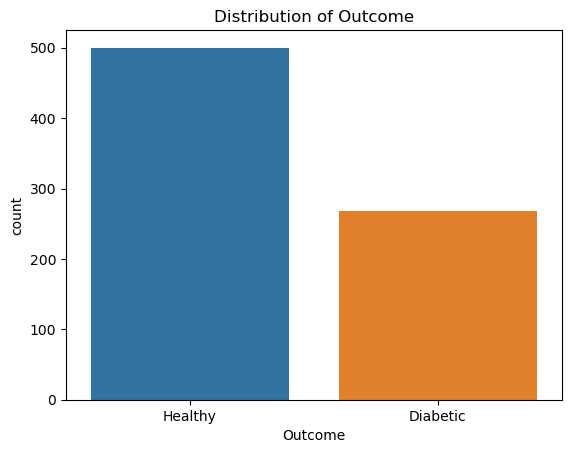

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
labels = ['Healthy', 'Diabetic']
sns.countplot(x='Outcome', data=data)
plt.xticks(ticks=[0,1],labels=labels)
plt.title('Distribution of Outcome')
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_8032\654674923.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(index, value, f'{zero_percentage[index]:.2f}% - {value}', ha='center', va='bottom')


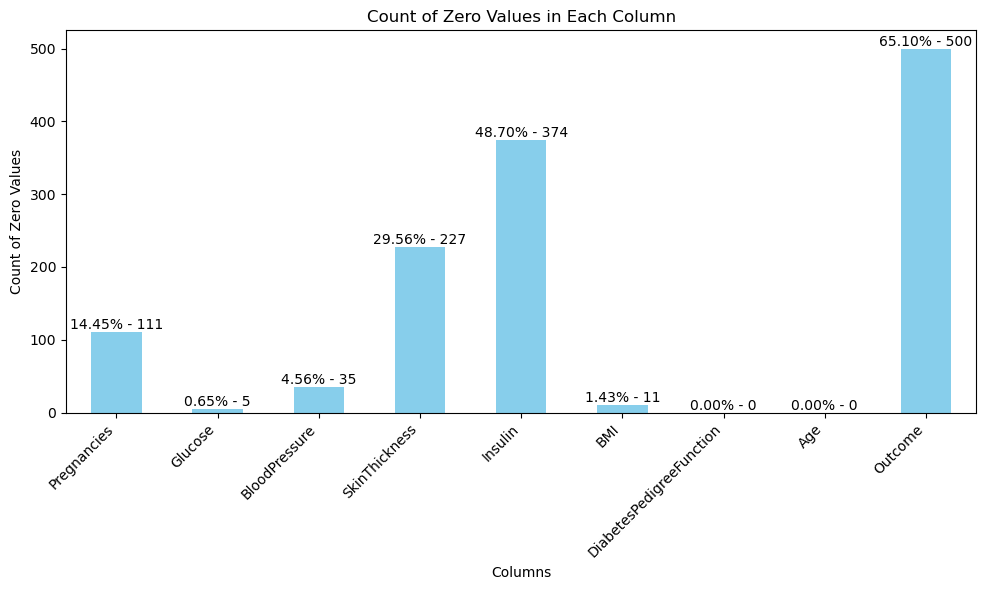

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
 
# Calculate count and percentage of 0 values in each column
zero_count = (data == 0).sum()
total_count = len(data)
zero_percentage = (zero_count / total_count) * 100

# Plotting vertical bar plot to visualize 0 values count
plt.figure(figsize=(10, 6))
barplot = zero_count.plot(kind='bar', color='skyblue')

# Annotating each bar with percentage and count of 0 values
for index, value in enumerate(zero_count):
    plt.text(index, value, f'{zero_percentage[index]:.2f}% - {value}', ha='center', va='bottom')

plt.title('Count of Zero Values in Each Column')
plt.xlabel('Columns')
plt.ylabel('Count of Zero Values')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels diagonally for better readability
plt.tight_layout()
plt.show()


### There is a lot of zeroes in['Glucose','BloodPressure','SkinThickness','Insulin','BMI'] so we gonna make them as null

# make 0 = null as NaN

In [18]:
import numpy as np
data[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] =data[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.NaN)

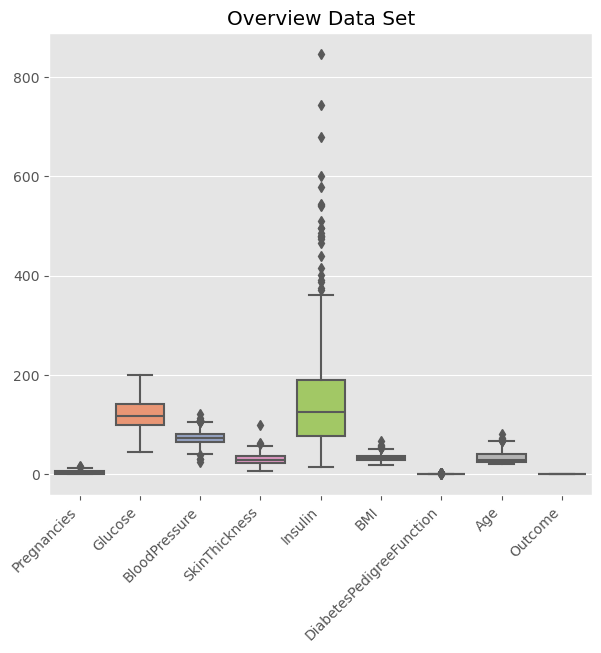

In [19]:
plt.style.use('ggplot') 

plt.figure(figsize=(7, 6))  
plt.title("Overview Data Set")
plt.xticks(rotation=45, ha='right')
sns.boxplot(data=data, orient='v', palette='Set2')

plt.show()

# fill the Missing values using median

In [20]:
import pandas as pd

# Calculate medians for each attribute based on Outcome
medians = data.groupby("Outcome")[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].median()

# Fill missing values based on Outcome
for outcome in [0, 1]:
    mask = (data["Outcome"] == outcome)
    data.loc[mask, ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = data.loc[mask, ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].fillna(medians.loc[outcome])

# Features Selection 

In [22]:
#Using round for easy reading
data.corr().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.00,0.13,0.21,0.09,0.06,0.02,-0.03,0.54,0.22
Glucose,0.13,1.00,0.23,0.23,0.49,0.24,0.14,0.27,0.50
BloodPressure,0.21,0.23,1.00,0.20,0.07,0.29,-0.00,0.33,0.17
SkinThickness,0.09,0.23,0.20,1.00,0.20,0.57,0.11,0.13,0.30
Insulin,0.06,0.49,0.07,0.20,1.00,0.24,0.15,0.12,0.38
BMI,0.02,0.24,0.29,0.57,0.24,1.00,0.15,0.03,0.32
DiabetesPedigreeFunction,-0.03,0.14,-0.00,0.11,0.15,0.15,1.00,0.03,0.17
Age,0.54,0.27,0.33,0.13,0.12,0.03,0.03,1.00,0.24
Outcome,0.22,0.50,0.17,0.30,0.38,0.32,0.17,0.24,1.00


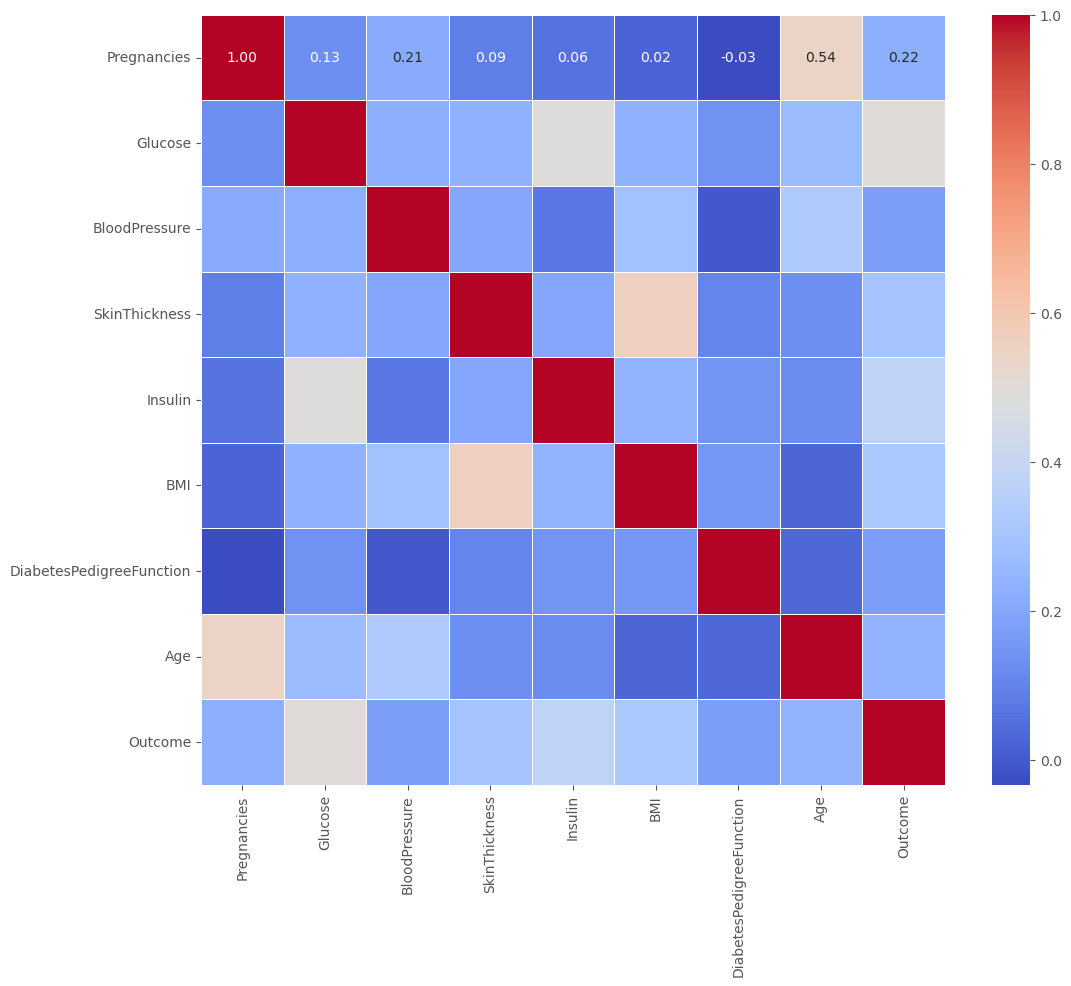

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier

X = data.drop(columns=['Outcome']) 
y = data['Outcome']

# Define the model
random_forest_model = RandomForestClassifier()


#Feature Importance (Random Forest)
random_forest_model.fit(X, y)
feature_importances = random_forest_model.feature_importances_
sorted_indices = feature_importances.argsort()[::-1]
k = 6  # Adjust as needed
selected_features_rf = X.columns[sorted_indices[:k]]
print("Selected Features using Random Forest Feature Importance:")
print(selected_features_rf)

Selected Features using Random Forest Feature Importance:
Index(['Insulin', 'SkinThickness', 'Glucose', 'Age', 'BMI',
       'DiabetesPedigreeFunction'],
      dtype='object')


### We observed the greatest features that have a strong correlation with Output 
### Random Forest Feature Importance[Insulin,Glucose,SkinThickness,BMI,Age,DiabetesPedigreeFunction]

In [27]:
#Drop Features
columns_to_drop = ["Pregnancies","BloodPressure"]
data2 = data.drop(columns=columns_to_drop)
#create a new DataFrame 
data2 = pd.DataFrame(data2)
data2

,Glucose,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148.0,35.0,169.5,33.6,0.627,50,1
1,85.0,29.0,102.5,26.6,0.351,31,0
2,183.0,32.0,169.5,23.3,0.672,32,1
3,89.0,23.0,94.0,28.1,0.167,21,0
4,137.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...
763,101.0,48.0,180.0,32.9,0.171,63,0
764,122.0,27.0,102.5,36.8,0.340,27,0
765,121.0,23.0,112.0,26.2,0.245,30,0
766,126.0,32.0,169.5,30.1,0.349,47,1


C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


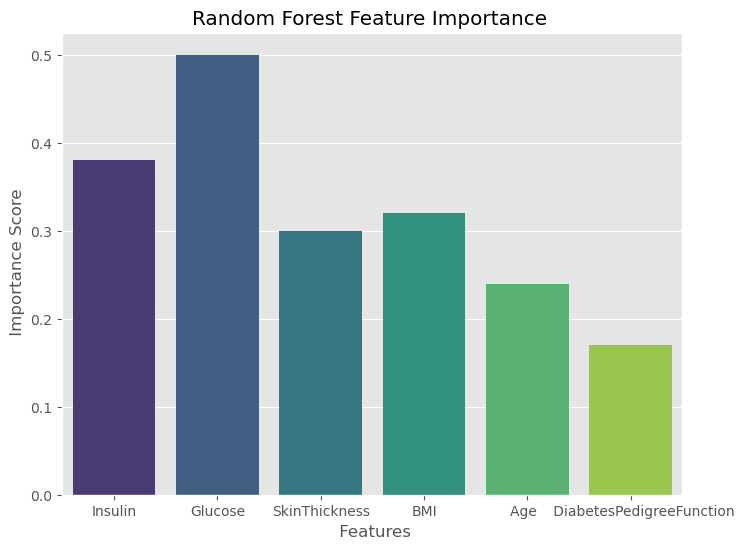

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns


features = ['Insulin', 'Glucose', 'SkinThickness', 'BMI', 'Age  ', '      DiabetesPedigreeFunction']
importance_scores = [0.38, 0.50, 0.30, 0.32,0.24 , 0.17]  # Example scores

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=features , y=importance_scores, palette='viridis')
plt.xlabel(' Features')
plt.ylabel(' Importance Score')
plt.title('Random Forest Feature Importance ')
plt.show()


In [28]:
data2.describe().T

,count,mean,std,min,25%,50%,75%,max
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [30]:
data2

,Glucose,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148.0,35.0,169.5,33.6,0.627,50,1
1,85.0,29.0,102.5,26.6,0.351,31,0
2,183.0,32.0,169.5,23.3,0.672,32,1
3,89.0,23.0,94.0,28.1,0.167,21,0
4,137.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...
763,101.0,48.0,180.0,32.9,0.171,63,0
764,122.0,27.0,102.5,36.8,0.340,27,0
765,121.0,23.0,112.0,26.2,0.245,30,0
766,126.0,32.0,169.5,30.1,0.349,47,1


# Over Sampling 

In [31]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = data2.drop('Outcome', axis=1)
y = data2['Outcome']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Perform oversampling on the training set
oversampler = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

# Output the shape of the resampled dataset
print("Shape of the resampled dataset:", X_train_resampled.shape, y_train_resampled.shape)


Shape of the resampled dataset: (802, 6) (802,)


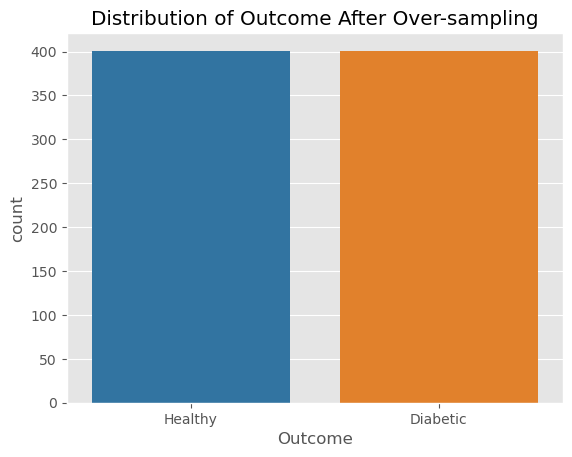

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming resampled_df is already defined as per your previous code
resampled_df = pd.DataFrame(X_train_resampled, columns=X_train.columns)
resampled_df['Outcome'] = y_train_resampled

# Define the labels for the x-axis ticks
labels = ['Healthy', 'Diabetic']

# Specify the colors as dark blue and dark orange
colors = ["#1f77b4", "#ff7f0e"]

# Plotting the count plot
sns.countplot(x='Outcome', data=resampled_df, palette=colors)
plt.xticks(ticks=[0, 1], labels=labels)
plt.title('Distribution of Outcome After Over-sampling')
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
X_selected = resampled_df.drop('Outcome', axis=1)
y_selected = resampled_df['Outcome']

## train_test_split method

In [24]:
#Neural Network
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import StandardScaler

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y_selected, test_size=0.2, random_state=35)

# Feature scaling 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_selected)
X_test = scaler.transform(X_test_selected)

# neural network model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train_selected, epochs=12, batch_size=34, validation_data=(X_test, y_test_selected))

# Evaluating the model 
loss, accuracy = model.evaluate(X_test, y_test_selected)
print(f'Test accuracy: {accuracy}')




Epoch 1/12


19/19 [==============================] - 2s 26ms/step - loss: 0.6210 - accuracy: 0.7020 - val_loss: 0.6072 - val_accuracy: 0.6770
Epoch 2/12
19/19 [==============================] - 0s 5ms/step - loss: 0.5299 - accuracy: 0.7800 - val_loss: 0.5604 - val_accuracy: 0.7081
Epoch 3/12
19/19 [==============================] - 0s 4ms/step - loss: 0.4670 - accuracy: 0.8128 - val_loss: 0.5432 - val_accuracy: 0.7205
Epoch 4/12
19/19 [==============================] - 0s 4ms/step - loss: 0.4343 - accuracy: 0.8253 - val_loss: 0.5327 - val_accuracy: 0.7453
Epoch 5/12
19/19 [==============================] - 0s 5ms/step - loss: 0.4123 - accuracy: 0.8331 - val_loss: 0.5325 - val_accuracy: 0.7516
Epoch 6/12
19/19 [==============================] - 0s 5ms/step - loss: 0.3967 - accuracy: 0.8300 - val_loss: 0.5208 - val_accuracy: 0.7516
Epoch 7/12
19/19 [==============================] - 0s 6ms/step - loss: 0.3824 - accuracy: 0.8378 - val_loss: 0.5128 - val_accuracy: 0.7640
Epoch 8/12
19/

In [25]:
# Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y_selected, test_size=0.2, random_state=35)

# Standardize the features
scaler = StandardScaler()
X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)

# Logistic Regression model
logreg_model = LogisticRegression(random_state=35)

logreg_model.fit(X_train_selected_scaled, y_train_selected)

# predictions 
y_pred_logreg = logreg_model.predict(X_test_selected_scaled)

# Evaluate the model performance
print("Logistic Regression:")
print("Confusion Matrix:")
print(confusion_matrix(y_test_selected, y_pred_logreg))
print("\nClassification Report:")
print(classification_report(y_test_selected, y_pred_logreg))

Logistic Regression:
Confusion Matrix:
[[50 19]
 [26 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.72      0.69        69
           1       0.78      0.72      0.75        92

    accuracy                           0.72       161
   macro avg       0.72      0.72      0.72       161
weighted avg       0.73      0.72      0.72       161



In [26]:
#Support Vector Machine
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y_selected, test_size=0.2, random_state=35)

# Feature scaling 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_selected)
X_test = scaler.transform(X_test_selected)

# Creating an SVM model
# RBF kernel
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')  

#fit model
svm_model.fit(X_train, y_train_selected)

# Predictions 
y_pred = svm_model.predict(X_test)

# Calculating accuracy
print("\nSupport Vector Machine (SVM) Performance:")
print("Confusion Matrix:")
print(confusion_matrix(y_test_selected, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_selected, y_pred))


Support Vector Machine (SVM) Performance:
Confusion Matrix:
[[55 14]
 [10 82]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        69
           1       0.85      0.89      0.87        92

    accuracy                           0.85       161
   macro avg       0.85      0.84      0.85       161
weighted avg       0.85      0.85      0.85       161



In [27]:
# GridSearchCV , RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y_selected, test_size=0.2, random_state=35)

# Standardize the features
scaler = StandardScaler()
X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=35)

#Grid Search CV
grid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring='accuracy')

# Fit model
grid_search.fit(X_train_selected_scaled, y_train_selected)

print("Best Parameters:", grid_search.best_params_)

# predictions
y_pred_tuned_selected = grid_search.best_estimator_.predict(X_test_selected_scaled)

# Evaluate the model performance after tuning
print("\nAfter Hyperparameter Tuning:")
print("Confusion Matrix:")
print(confusion_matrix(y_test_selected, y_pred_tuned_selected))
print("\nClassification Report:")
print(classification_report(y_test_selected, y_pred_tuned_selected))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

After Hyperparameter Tuning:
Confusion Matrix:
[[59 10]
 [ 5 87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        69
           1       0.90      0.95      0.92        92

    accuracy                           0.91       161
   macro avg       0.91      0.90      0.90       161
weighted avg       0.91      0.91      0.91       161



## Cross-Validation Method

In [28]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import StandardScaler

In [45]:
#NN
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import accuracy_score

# Number of splits for cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=35)

# Lists to store results for each fold
accuracies = []

for fold_idx, (train_index, test_index) in enumerate(skf.split(X_selected, y_selected), 1):
    X_train_selected, X_test_selected = X_selected.iloc[train_index], X_selected.iloc[test_index]
    y_train_selected, y_test_selected = y_selected.iloc[train_index], y_selected.iloc[test_index]
    
    # Feature scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_selected)
    X_test = scaler.transform(X_test_selected)
    
    # Neural network model
    model = Sequential()
    model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compiling the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Training the model
    model.fit(X_train, y_train_selected, epochs=12, batch_size=34, validation_data=(X_test, y_test_selected), verbose=0)
    
    # Evaluating the model
    _, accuracy = model.evaluate(X_test, y_test_selected, verbose=0)
    accuracies.append(accuracy)
    print(f'Fold {fold_idx} accuracy: {accuracy}')

# Find the highest accuracy and corresponding fold
best_fold_index = np.argmax(accuracies)
highest_accuracy = accuracies[best_fold_index]

print(f'\nHighest accuracy: {highest_accuracy} (Fold {best_fold_index + 1})')

# Calculate and print average cross-validation accuracy
avg_accuracy = np.mean(accuracies)
print(f"Average cross-validation accuracy: {avg_accuracy}")

Fold 1 accuracy: 0.8633540272712708
Fold 2 accuracy: 0.9006211161613464
Fold 3 accuracy: 0.862500011920929
Fold 4 accuracy: 0.824999988079071
Fold 5 accuracy: 0.862500011920929

Highest accuracy: 0.9006211161613464 (Fold 2)
Average cross-validation accuracy: 0.8627950310707092


In [46]:
#Logistic Regression
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize StratifiedKFold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=35)

# Lists to store results
accuracies = []

for fold_idx, (train_index, test_index) in enumerate(skf.split(X_selected, y_selected), 1):
    X_train_selected, X_test_selected = X_selected.iloc[train_index], X_selected.iloc[test_index]
    y_train_selected, y_test_selected = y_selected.iloc[train_index], y_selected.iloc[test_index]
    
    # Standardize the features
    scaler = StandardScaler()
    X_train_selected_scaled = scaler.fit_transform(X_train_selected)
    X_test_selected_scaled = scaler.transform(X_test_selected)
    
    # Logistic Regression model
    logreg_model = LogisticRegression(random_state=35)
    logreg_model.fit(X_train_selected_scaled, y_train_selected)
    
    # Predictions
    y_pred_logreg = logreg_model.predict(X_test_selected_scaled)
    
    # Accuracy
    accuracy = accuracy_score(y_test_selected, y_pred_logreg)
    accuracies.append(accuracy)
    
    # Print fold accuracy
    print(f"Fold accuracy {fold_idx}: {accuracy}")

# Find the highest accuracy and corresponding fold
best_fold_index = np.argmax(accuracies)
highest_accuracy = accuracies[best_fold_index]

print(f"\nHighest accuracy: {highest_accuracy} (Fold {best_fold_index + 1})")

# Calculate and print average cross-validation accuracy
avg_accuracy = np.mean(accuracies)
print(f"Average cross-validation accuracy: {avg_accuracy}")

Fold accuracy 1: 0.7701863354037267
Fold accuracy 2: 0.8385093167701864
Fold accuracy 3: 0.775
Fold accuracy 4: 0.71875
Fold accuracy 5: 0.75625

Highest accuracy: 0.8385093167701864 (Fold 2)
Average cross-validation accuracy: 0.7717391304347826


In [47]:
#Support Vector Machine
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize StratifiedKFold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=35)

# Lists to store results
accuracies = []

for fold_idx, (train_index, test_index) in enumerate(skf.split(X_selected, y_selected), 1):
    X_train_selected, X_test_selected = X_selected.iloc[train_index], X_selected.iloc[test_index]
    y_train_selected, y_test_selected = y_selected.iloc[train_index], y_selected.iloc[test_index]
    
    # Feature scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_selected)
    X_test = scaler.transform(X_test_selected)
    
    # SVM model with RBF kernel
    svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
    svm_model.fit(X_train, y_train_selected)
    
    # Predictions
    y_pred = svm_model.predict(X_test)
    
    # Accuracy
    accuracy = accuracy_score(y_test_selected, y_pred)
    accuracies.append(accuracy)
    
    # Print fold accuracy
    print(f"Fold accuracy {fold_idx}: {accuracy}")

# Find the highest accuracy and corresponding fold
best_fold_index = np.argmax(accuracies)
highest_accuracy = accuracies[best_fold_index]

print(f"\nHighest accuracy: {highest_accuracy} (Fold {best_fold_index + 1})")

# Calculate and print average cross-validation accuracy
avg_accuracy = np.mean(accuracies)
print(f"Average cross-validation accuracy: {avg_accuracy}")

Fold accuracy 1: 0.8819875776397516
Fold accuracy 2: 0.9130434782608695
Fold accuracy 3: 0.875
Fold accuracy 4: 0.825
Fold accuracy 5: 0.8625

Highest accuracy: 0.9130434782608695 (Fold 2)
Average cross-validation accuracy: 0.8715062111801242


In [48]:
#GridSearchCV with RandomForestClassifier
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

# Initialize StratifiedKFold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=35)

# Lists to store results
accuracies = []

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Iterate over each fold
for fold_idx, (train_index, test_index) in enumerate(skf.split(X_selected, y_selected), 1):
    X_train_selected, X_test_selected = X_selected.iloc[train_index], X_selected.iloc[test_index]
    y_train_selected, y_test_selected = y_selected.iloc[train_index], y_selected.iloc[test_index]
    
    # Standardize the features
    scaler = StandardScaler()
    X_train_selected_scaled = scaler.fit_transform(X_train_selected)
    X_test_selected_scaled = scaler.transform(X_test_selected)
    
    # Random Forest Classifier
    rf_classifier = RandomForestClassifier(random_state=35)
    
    # Grid Search CV
    grid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring='accuracy')
    
    # Fit model
    grid_search.fit(X_train_selected_scaled, y_train_selected)
    
    # Best estimator from GridSearchCV
    best_rf_model = grid_search.best_estimator_
    
    # Predictions
    y_pred_tuned_selected = best_rf_model.predict(X_test_selected_scaled)
    
    # Accuracy
    accuracy = np.mean(y_pred_tuned_selected == y_test_selected)
    accuracies.append(accuracy)
    
    # Print fold accuracy
    print(f"Fold accuracy {fold_idx}: {accuracy}")

# Find the highest accuracy and corresponding fold
best_fold_index = np.argmax(accuracies)
highest_accuracy = accuracies[best_fold_index]

print(f"\nHighest accuracy: {highest_accuracy} (Fold {best_fold_index + 1})")

# Calculate and print average cross-validation accuracy
avg_accuracy = np.mean(accuracies)
print(f"Average cross-validation accuracy: {avg_accuracy}")

Fold accuracy 1: 0.9316770186335404
Fold accuracy 2: 0.906832298136646
Fold accuracy 3: 0.93125
Fold accuracy 4: 0.90625
Fold accuracy 5: 0.925

Highest accuracy: 0.9316770186335404 (Fold 1)
Average cross-validation accuracy: 0.9202018633540373


In [54]:
#RandomForestClassifier with RandomizedSearchCV
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint

# Standardize the features
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# Initialize the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=35)

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None] + list(randint(5, 50).rvs(10)),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20)
}

# Define the cross-validation strategy (stratified k-fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform RandomizedSearchCV for hyperparameter tuning with cross-validation
random_search = RandomizedSearchCV(rf_classifier, param_distributions=param_dist, n_iter=100, cv=cv, scoring='accuracy', random_state=35)
random_search.fit(X_selected_scaled, y_selected)

# Get the best parameters
best_params = random_search.best_params_
print("Best Parameters:", best_params)

print()
print()

# Train a new classifier using the best parameters
best_rf_classifier = RandomForestClassifier(random_state=35, **best_params)
best_rf_classifier.fit(X_selected_scaled, y_selected)

# Make predictions using cross-validation
y_pred_cv = random_search.best_estimator_.predict(X_selected_scaled)

# Calculate accuracy
accuracy_cv = accuracy_score(y_selected, y_pred_cv)
print("Accuracy after hyperparameter tuning (cross-validation):", accuracy_cv)

print()
print()

# Evaluate the model performance after tuning
print("\nAfter Hyperparameter Tuning (cross-validation):")
print("Confusion Matrix:")
print(confusion_matrix(y_selected, y_pred_cv))
print("\nClassification Report:")
print(classification_report(y_selected, y_pred_cv))


Best Parameters: {'max_depth': 17, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 79}
Accuracy after hyperparameter tuning (cross-validation): 0.9875311720698254

After Hyperparameter Tuning (cross-validation):
Confusion Matrix:
[[396   5]
 [  5 396]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       401
           1       0.99      0.99      0.99       401

    accuracy                           0.99       802
   macro avg       0.99      0.99      0.99       802
weighted avg       0.99      0.99      0.99       802

